# ASAP warnings

<!-- markdownlint-disable MD013 -->

In [4]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import calendar
import re

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns

from src.constants import *
from src.datasources import asap, seas5
from src.utils import dekad, blob_utils, rp_calc

In [14]:
asap.process_asap_warnings()

## Load pre-filtered data

And do some light processing

In [21]:
df_asap = asap.load_processed_asap_warnings()

In [22]:
def get_alert_gr_int(alert_gr_str):
    str_prefix_removed = alert_gr_str.removeprefix("Warning group ")
    try:
        return int(str_prefix_removed)
    except ValueError:
        return 0


for crop_range in ["crop", "range"]:
    df_asap[f"w_{crop_range}_gr_int"] = df_asap[f"w_{crop_range}_gr"].apply(
        get_alert_gr_int
    )

df_asap["year"] = df_asap["date"].dt.year
df_asap = df_asap[df_asap["year"] <= 2025].copy()

In [23]:
df_asap[
    [x for x in df_asap.columns if "w_crop" in x]
].drop_duplicates().sort_values("w_crop")

,w_crop,w_crop_na,w_crop_de,w_crop_gr,w_crop_gr_int
189423,0,No warning,Season is active but no relevant anomalies are...,No warning,0
374127,2,Warning level 1,At least 25% of the active area is affected by...,Warning group 1,1
376497,3,Warning level 1,At least 25% of the active area is affected by...,Warning group 1,1
483047,4,Warning level 1+,At least 25% of the active area is affected by...,Warning group 1,1
120751,5,Warning level 2,At least 25% of the active area is affected by...,Warning group 2,2
483057,6,Warning level 3,At least 25% of the active area is affected by...,Warning group 3,3
142063,7,Warning level 3,At least 25% of the active area is affected by...,Warning group 3,3
909295,8,Warning level 3+,At least 25% of the active area is affected by...,Warning group 3,3
542247,9,Warning level 4,Season is in the senescence stage with at leas...,Warning group 4,4
33135,10,No warning with exceptional conditions,Season is active but no relevant negative anom...,No warning,0


Check that the "Warning with exceptional conditions" don't happen too often - looks fine.

<Axes: xlabel='w_crop'>

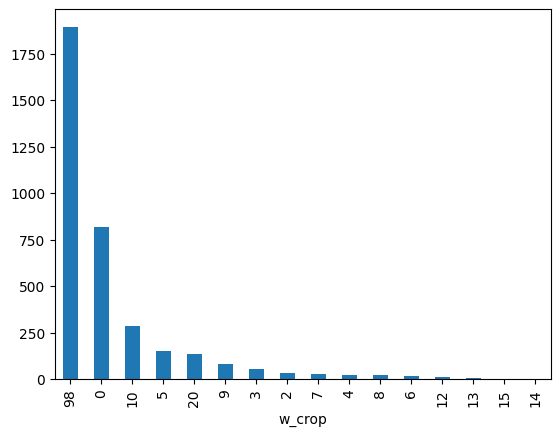

In [24]:
df_asap["w_crop"].value_counts().plot.bar()

In [25]:
all_years = df_asap["date"].dt.year.unique()

In [26]:
all_years

array([2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015,
       2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004,
       2003, 2002, 2001], dtype=int32)

## Cycle through ASAP warning options

There's various ways to combine the warnings, but I broke it down to:

- either `OR` or `AND` condition to combine crop and range
- minimum number of admin1s with the alert level
- minimum alert level

In [27]:
# options

crop_range_options = ["OR", "AND"]
minimum_adm1s_options = [1, 2, 3, 4]
alert_level_options = [1, 2, 3, 4]

In [30]:
# set first possible trigger dekad to 3rd dekad of July
min_dekad = 21
# set last possible trigger dekad to 3rd dekad of Sep
max_dekad = 27

df_monitoring = df_asap[
    (df_asap["dekad"] >= min_dekad) & (df_asap["dekad"] <= max_dekad)
]

dfs = []
for crop_range in crop_range_options:
    for minimum_adm1s in minimum_adm1s_options:
        for alert_level in alert_level_options:
            dff = df_monitoring.copy()
            if crop_range == "OR":
                dff["indicator"] = dff[
                    ["w_crop_gr_int", "w_range_gr_int"]
                ].max(axis=1)
            elif crop_range == "AND":
                dff["indicator"] = dff[
                    ["w_crop_gr_int", "w_range_gr_int"]
                ].min(axis=1)
            else:
                raise ValueError("invalid crop_range")
            dff = dff[dff["indicator"] >= alert_level]
            adm_counts = (
                dff.groupby("year")
                .agg(
                    count_adm1s=("ADM1_PCODE", "nunique"),
                    min_dekad=("dekad", "min"),
                )
                .reset_index()
            )
            display(adm_counts)
            trigger_years = adm_counts[
                adm_counts["count_adm1s"] >= minimum_adm1s
            ][["year", "min_dekad"]]
            trigger_years[["crop_range", "minadm1s", "al"]] = (
                crop_range,
                minimum_adm1s,
                alert_level,
            )
            dfs.append(trigger_years)

df_triggers = pd.concat(dfs, ignore_index=True)

,year,count_adm1s,min_dekad
0,2001,3,26
1,2002,4,21
2,2004,4,21
3,2005,3,21
4,2006,4,21
5,2007,3,21
6,2008,2,21
7,2009,2,21
8,2010,2,21
9,2011,4,21


,year,count_adm1s,min_dekad
0,2001,1,26
1,2002,4,21
2,2004,2,21
3,2006,4,21
4,2009,2,21
5,2010,2,21
6,2011,3,21
7,2014,1,24
8,2015,3,21
9,2019,3,21


,year,count_adm1s,min_dekad
0,2002,4,21
1,2004,2,22
2,2006,3,21
3,2009,2,21
4,2010,1,21
5,2011,1,21
6,2014,1,24
7,2015,1,21
8,2019,1,27
9,2024,1,21


,year,count_adm1s,min_dekad


,year,count_adm1s,min_dekad
0,2001,3,26
1,2002,4,21
2,2004,4,21
3,2005,3,21
4,2006,4,21
5,2007,3,21
6,2008,2,21
7,2009,2,21
8,2010,2,21
9,2011,4,21


...

,year,count_adm1s,min_dekad


,year,count_adm1s,min_dekad
0,2001,1,26
1,2002,4,21
2,2004,4,22
3,2005,1,21
4,2006,3,21
5,2007,3,21
6,2008,2,21
7,2009,2,21
8,2010,2,21
9,2011,4,21


,year,count_adm1s,min_dekad
0,2002,3,21
1,2004,2,23
2,2006,3,21
3,2009,2,21
4,2010,1,21
5,2011,3,21
6,2015,2,21
7,2019,2,21
8,2020,1,21
9,2024,1,21


,year,count_adm1s,min_dekad
0,2002,3,21
1,2004,2,23
2,2006,2,21
3,2009,1,21
4,2015,1,21
5,2019,1,27


,year,count_adm1s,min_dekad


In [32]:
df_triggers[
    (df_triggers["crop_range"] == "OR")
    & (df_triggers["minadm1s"] == 4)
    & (df_triggers["al"] == 4)
]

,year,min_dekad,crop_range,minadm1s,al


### Calculate return period

In [33]:
df_rps = (
    df_triggers.groupby(["crop_range", "minadm1s", "al"])
    .agg(count=("year", "size"), min_dekad=("min_dekad", "mean"))
    .reset_index()
)
df_rps["rp"] = (len(all_years) + 1) / df_rps["count"]
df_rps = df_rps.sort_values("rp", ascending=False)
df_rps

,crop_range,minadm1s,al,count,min_dekad,rp
21,OR,4,3,1,21.000000,26.000000
8,AND,3,3,1,21.000000,26.000000
20,OR,4,2,2,21.000000,13.000000
18,OR,3,3,2,21.000000,13.000000
5,AND,2,3,3,21.666667,8.666667
7,AND,3,2,3,21.000000,8.666667
9,AND,4,1,3,21.333333,8.666667
19,OR,4,1,4,21.000000,6.500000
15,OR,2,3,4,21.250000,6.500000
17,OR,3,2,5,21.000000,5.200000


### Plot RP of options

In [34]:
lower_rp, upper_rp = 4, 20

In [35]:
def plot_asap_heatmap(crop_range):
    bounds = [0, lower_rp, upper_rp, 1000]
    tick_bounds = bounds[1:-1]
    cmap = plt.cm.Spectral_r
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    crop_range_fr = "OU" if crop_range == "OR" else "ET"
    df_plot = df_rps[df_rps["crop_range"] == crop_range].pivot(
        values="rp", columns="minadm1s", index="al"
    )

    fig, ax = plt.subplots(dpi=200)

    sns.heatmap(df_plot, annot=True, cmap=cmap, norm=norm, ax=ax, cbar=False)

    ax.invert_yaxis()
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(
        f"Période de retour d'alertes ASAP\n(agricole {crop_range_fr} pâturage)"
    )
    ax.set_xlabel("Nombre de régions avec alerte")
    ax.set_ylabel("Niveau d'alerte minimum")

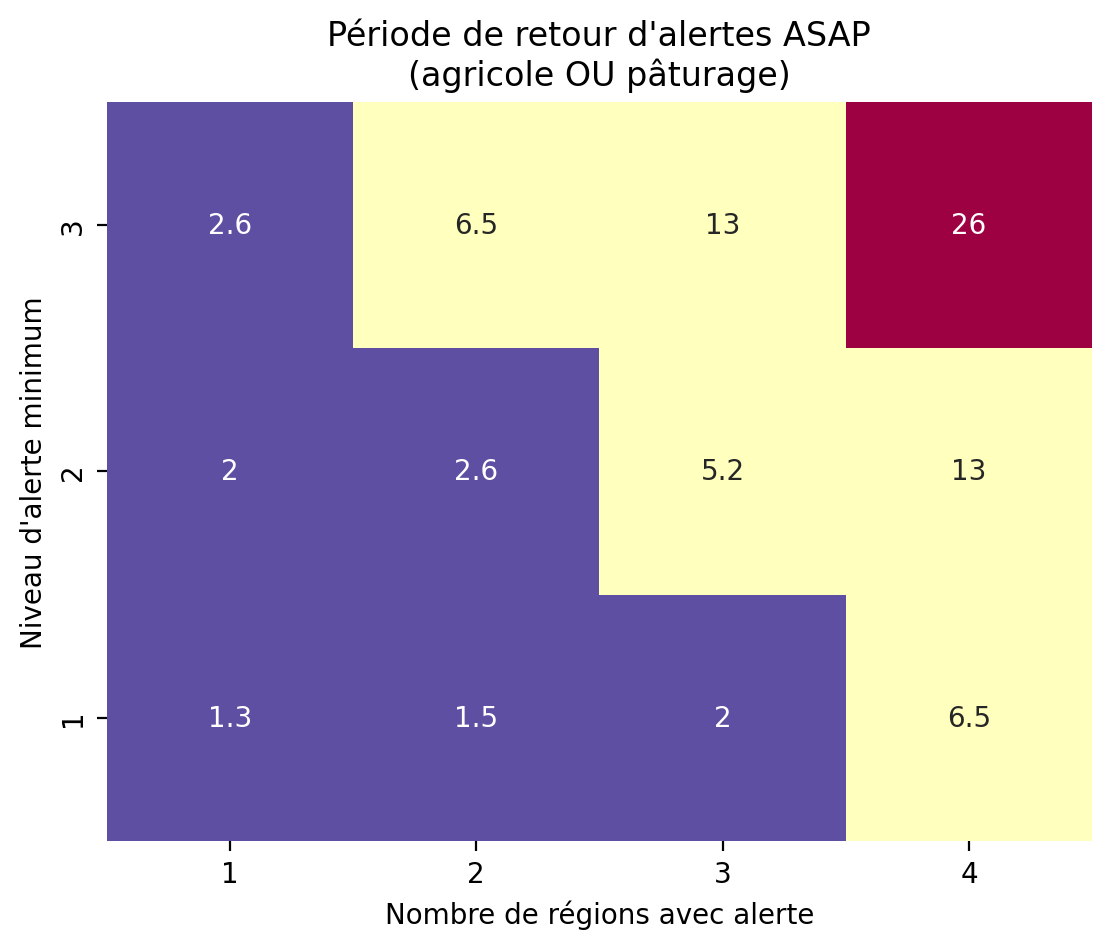

In [36]:
plot_asap_heatmap("OR")

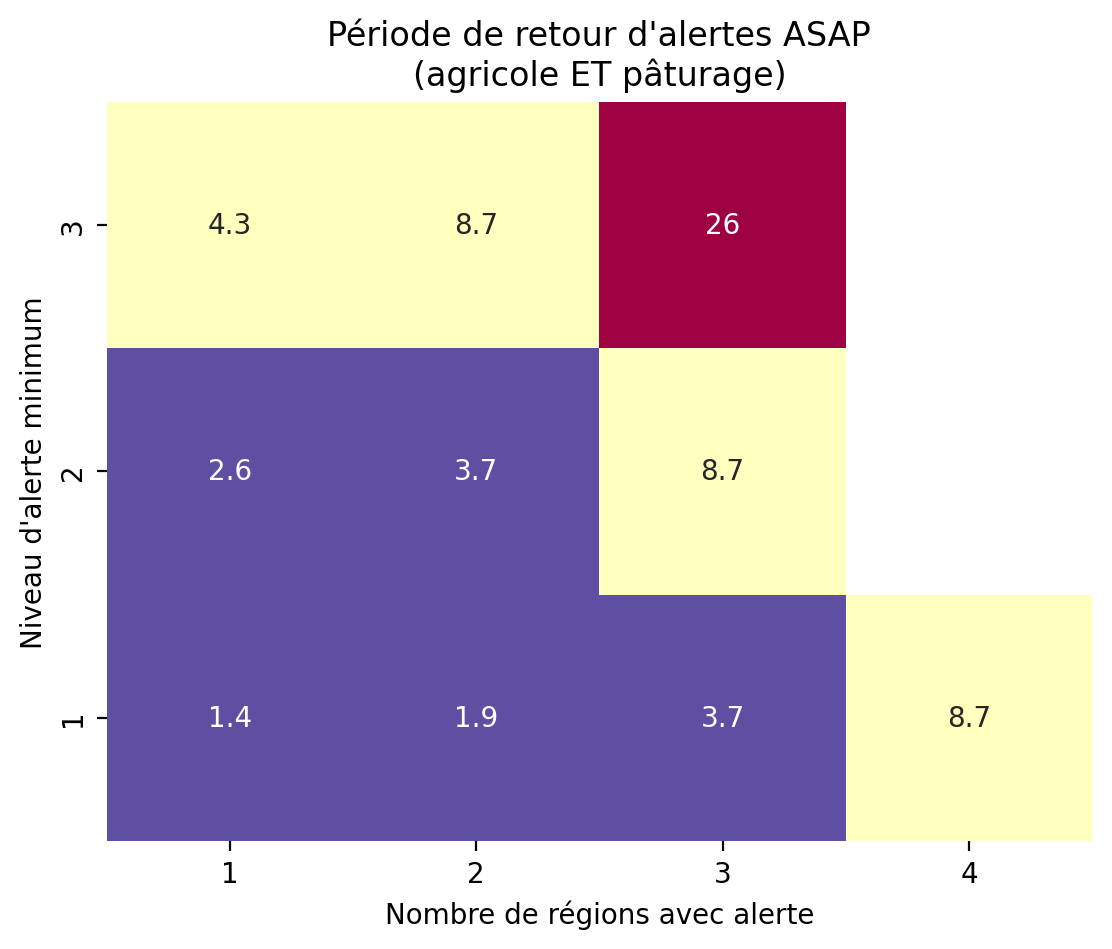

In [37]:
plot_asap_heatmap("AND")

### Plot trigger timing of options

In [38]:
def plot_asap_heatmap_min_dekad(crop_range):
    crop_range_fr = "OU" if crop_range == "OR" else "ET"
    df_plot = df_rps[df_rps["crop_range"] == crop_range].pivot(
        values="min_dekad", columns="minadm1s", index="al"
    )

    fig, ax = plt.subplots(dpi=200)

    sns.heatmap(
        df_plot, cmap="autumn_r", annot=True, ax=ax, cbar=False, fmt=".1f"
    )

    ax.invert_yaxis()
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(
        f"Première décade de déclenchement ASAP\n(agricole {crop_range_fr} pâturage)"
    )
    ax.set_xlabel("Nombre de régions avec alerte")
    ax.set_ylabel("Niveau d'alerte minimum")

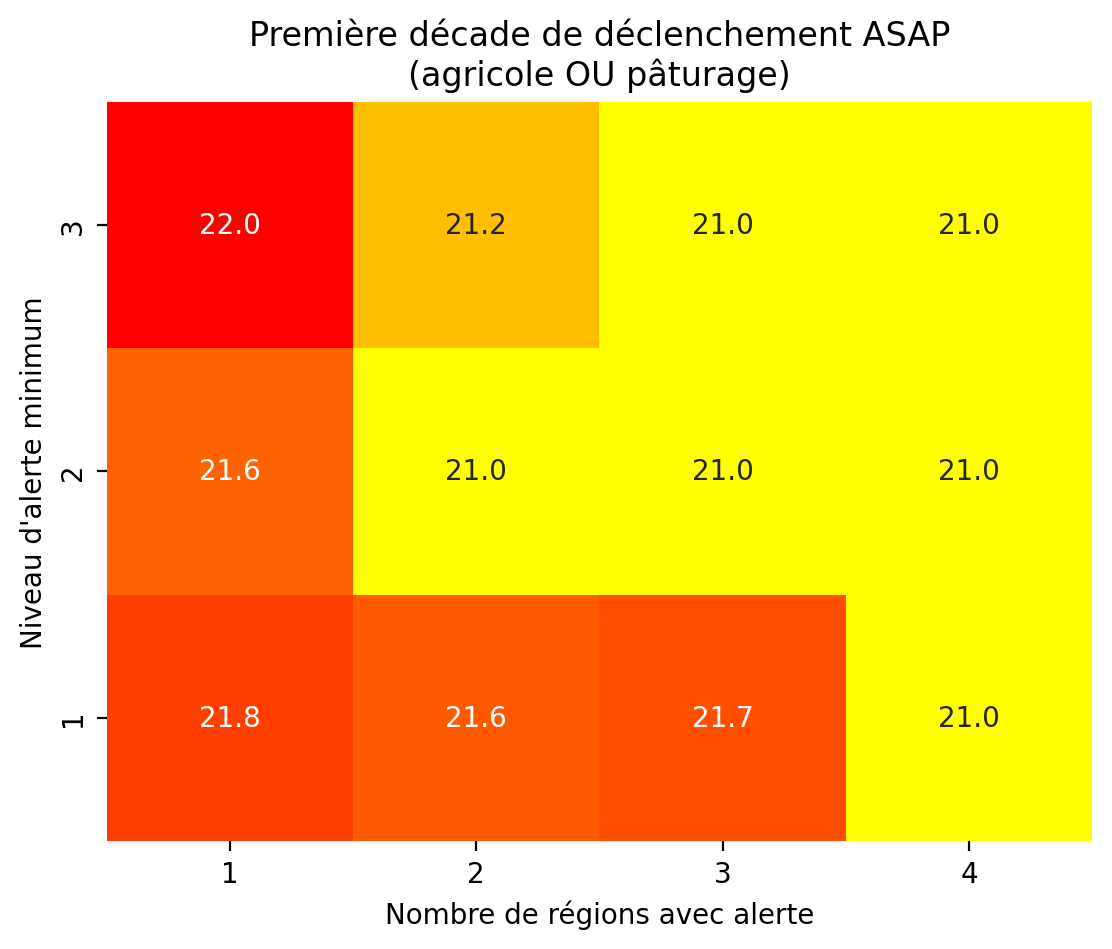

In [39]:
plot_asap_heatmap_min_dekad("OR")

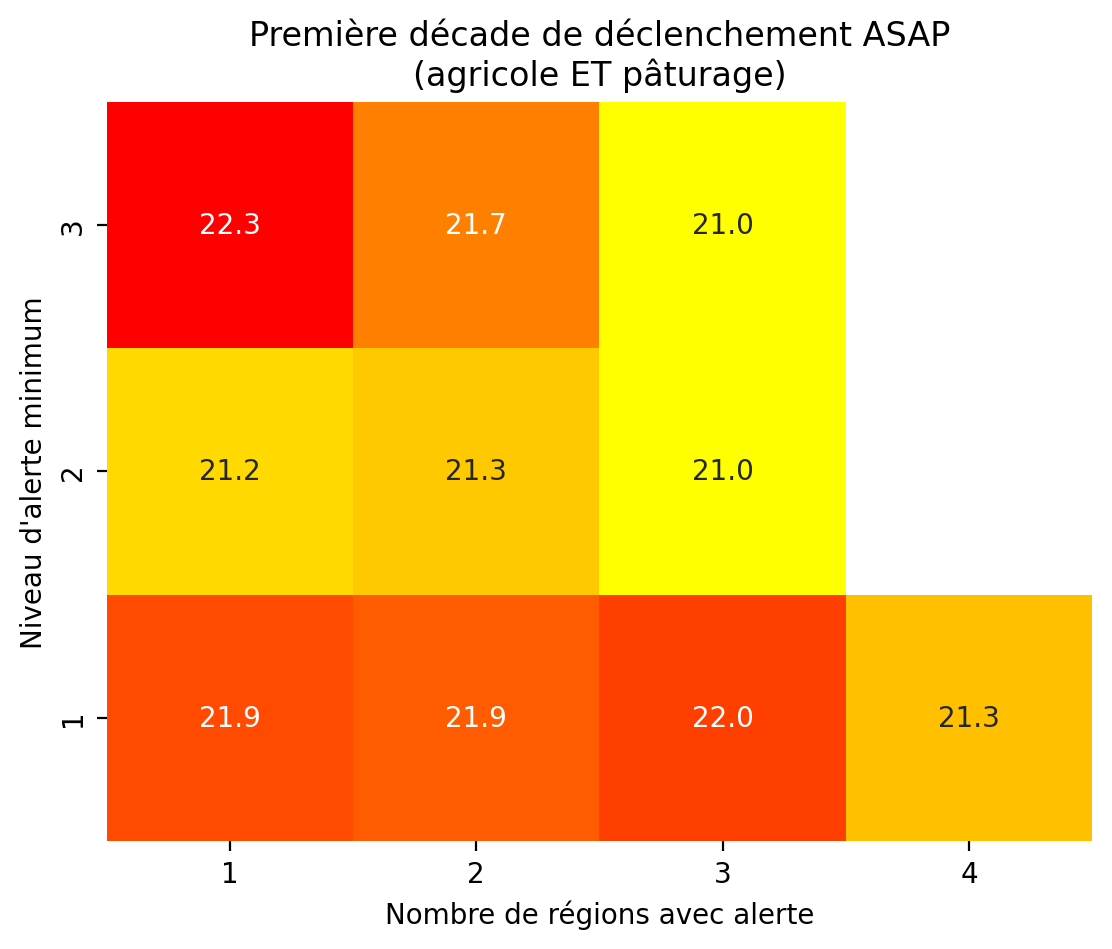

In [40]:
plot_asap_heatmap_min_dekad("AND")

In [41]:
# set naming structure for ASAP triggers
ASAP_COL = (
    "Niveau ≥ {al}<br>N. régions ≥ {minadm1s}<br>" "Ag. {crop_range_fr} Pât."
)

In [42]:
# set up reverse of naming structure
# in retropsect this could've all been avoided with proper grouping
# but this works for now
def extract_asap_params(formatted_string):
    # Define a regular expression pattern to match the expected format, allowing crop_range_fr to be a string
    pattern = r"Niveau ≥ (?P<al>\d+)<br>N\. régions ≥ (?P<minadm1s>\d+)<br>Ag\. (?P<crop_range_fr>[\w\s]+) Pât\."

    # Search the string for matches
    match = re.search(pattern, formatted_string)

    if match:
        # Extract the matched values
        al = match.group("al")
        minadm1s = match.group("minadm1s")
        crop_range_fr = match.group("crop_range_fr")
        return al, minadm1s, crop_range_fr
    else:
        raise ValueError("The string does not match the expected format")

### Check specific years triggered

In [43]:
df_asap_yearly = pd.DataFrame(data={"year": range(2001, 2025)})
for _, row in df_rps.iterrows():
    crop_range_fr = "OU" if row["crop_range"] == "OR" else "ET"
    col_name = ASAP_COL.format(
        al=row["al"], minadm1s=row["minadm1s"], crop_range_fr=crop_range_fr
    )
    df_triggers_f = df_triggers[
        (df_triggers["crop_range"] == row["crop_range"])
        & (df_triggers["al"] == row["al"])
        & (df_triggers["minadm1s"] == row["minadm1s"])
    ]
    df_asap_yearly[col_name] = df_asap_yearly["year"].apply(
        lambda x: x in df_triggers_f["year"].unique()
    )

In [44]:
crop_range

'AND'

In [45]:
df_triggers[
    (df_triggers["crop_range"] == crop_range)
    & (df_triggers["al"] == row["al"])
    & (df_triggers["minadm1s"] == row["minadm1s"])
]

,year,min_dekad,crop_range,minadm1s,al
101,2001,26,AND,1,1
102,2002,21,AND,1,1
103,2004,22,AND,1,1
104,2005,21,AND,1,1
105,2006,21,AND,1,1
106,2007,21,AND,1,1
107,2008,21,AND,1,1
108,2009,21,AND,1,1
109,2010,21,AND,1,1
110,2011,21,AND,1,1


In [59]:
def highlight_true(value):
    if isinstance(value, bool) and value is True or value == "Activation":
        return "background-color: crimson; color: white"
    elif (
        isinstance(value, bool)
        and value is False
        or value == "Pas d'activation"
    ):
        return "color: lightgrey"
    else:
        return ""


def display_asap_activations(crop_range):
    dff = df_rps[
        (df_rps["rp"] >= lower_rp)
        & (df_rps["rp"] <= upper_rp)
        & (df_rps["crop_range"] == crop_range)
    ]

    df_disp = pd.DataFrame(data={"year": range(2001, 2025)})
    for _, row in dff.iterrows():
        col_name = f'Niveau ≥ {row["al"]}<br>N. régions ≥ {row["minadm1s"]}'
        df_triggers_f = df_triggers[
            (df_triggers["crop_range"] == crop_range)
            & (df_triggers["al"] == row["al"])
            & (df_triggers["minadm1s"] == row["minadm1s"])
        ]
        df_disp[col_name] = df_disp["year"].apply(
            lambda x: x in df_triggers_f["year"].unique()
        )

    display(
        df_disp.sort_values("year", ascending=False)
        .rename(columns={"year": "Année"})
        .set_index("Année")
        .style.map(highlight_true)
    )

In [60]:
display_asap_activations("OR")

,Niveau ≥ 2N. régions ≥ 4,Niveau ≥ 3N. régions ≥ 3,Niveau ≥ 1N. régions ≥ 4,Niveau ≥ 3N. régions ≥ 2,Niveau ≥ 2N. régions ≥ 3
Année,,,,,
2024,False,False,False,False,False
2023,False,False,False,False,False
2022,False,False,False,False,False
2021,False,False,False,False,False
2020,False,False,False,False,False
2019,False,False,False,False,True
2018,False,False,False,False,False
2017,False,False,False,False,False
2016,False,False,False,False,False


In [61]:
display_asap_activations("AND")

,Niveau ≥ 3N. régions ≥ 2,Niveau ≥ 2N. régions ≥ 3,Niveau ≥ 1N. régions ≥ 4,Niveau ≥ 3N. régions ≥ 1
Année,,,,
2024,False,False,False,False
2023,False,False,False,False
2022,False,False,False,False
2021,False,False,False,False
2020,False,False,False,False
2019,False,False,False,True
2018,False,False,False,False
2017,False,False,False,False
2016,False,False,False,False


## Combined RP

### Load SEAS5

In [49]:
df_seas5 = seas5.load_seas5_stats(variable="rank")

In [50]:
df_seas5

,year,issued_month,q
0,1981,3,0.363636
1,1981,7,0.181818
2,1982,3,0.363636
3,1982,7,0.068182
4,1983,3,0.022727
...,...,...,...
83,2022,7,0.750000
84,2023,3,0.409091
85,2023,7,0.840909
86,2024,3,0.545455


In [51]:
df_seas5_yearly = df_seas5.pivot(
    index="year", columns="issued_month", values="q"
).reset_index()
df_seas5_yearly = df_seas5_yearly.rename(
    columns={x: f"issued_{x}" for x in [3, 7]}
)

### Merge with ASAP

In [52]:
df_both_yearly = df_seas5_yearly.merge(df_asap_yearly).sort_values(
    "year", ascending=False
)

In [53]:
df_both_yearly[ASAP_COL.format(al=4, crop_range_fr="OU", minadm1s=4)]

KeyError: 'Niveau ≥ 4<br>N. régions ≥ 4<br>Ag. OU Pât.'

Quickly check the individual RP of SEAS5

In [54]:
rp_based = False

rp_seas5 = 8
fixed_thresh = -0.75


for mo in [3, 7]:
    if rp_based:
        df_both_yearly[f"issued_{mo}_bool"] = df_both_yearly[
            f"issued_{mo}"
        ] < df_both_yearly[f"issued_{mo}"].quantile(1 / rp_seas5)
    else:
        df_both_yearly[f"issued_{mo}_bool"] = (
            df_both_yearly[f"issued_{mo}"] < fixed_thresh
        )
        print(f"issued month {mo}:")
        print((len(all_years) + 1) / df_both_yearly[f"issued_{mo}_bool"].sum())
        print()

issued month 3:
inf

issued month 7:
inf



/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_73264/3955251585.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  print((len(all_years) + 1) / df_both_yearly[f"issued_{mo}_bool"].sum())
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_73264/3955251585.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  print((len(all_years) + 1) / df_both_yearly[f"issued_{mo}_bool"].sum())


In [42]:
df_both_yearly[["year"] + [f"issued_{mo}_bool" for mo in [3, 7]]]

,year,issued_3_bool,issued_7_bool
23,2024,False,False
22,2023,False,False
21,2022,False,False
20,2021,False,False
19,2020,False,False
18,2019,False,False
17,2018,False,False
16,2017,False,False
15,2016,False,False
14,2015,False,False


### Determine combined RPs

In [43]:
asap_col = ASAP_COL.format(al=2, minadm1s=3, crop_range_fr="ET")

df_both_yearly.set_index("year")[
    ["issued_3_bool", "issued_7_bool", asap_col]
].style.map(highlight_true)

,issued_3_bool,issued_7_bool,Niveau ≥ 2N. régions ≥ 3Ag. ET Pât.
year,,,
2024,False,False,False
2023,False,False,False
2022,False,False,False
2021,False,False,False
2020,False,False,False
2019,False,False,False
2018,False,False,False
2017,False,False,False
2016,False,False,False


In [44]:
for mo in [3, 7]:
    df_both_yearly = rp_calc.calculate_one_group_rp(
        df_both_yearly, col_name=f"issued_{mo}"
    )

In [45]:
dicts = []

df_plot = df_both_yearly.copy()

asap_cols = [x for x in df_both_yearly.columns if "Niveau" in x]

for rank in range(len(df_plot)):
    df_plot["mar_trig"] = df_plot["issued_3_rank"] <= rank + 1
    df_plot["jul_trig"] = df_plot["issued_7_rank"] <= rank + 1
    rp_seas5_ind = (len(df_plot) + 1) / df_plot["mar_trig"].sum()
    df_plot["seas5_trig"] = df_plot[["mar_trig", "jul_trig"]].any(axis=1)
    rp_seas5_com = (len(df_plot) + 1) / df_plot["seas5_trig"].sum()
    for asap_col in asap_cols:
        rp_asap = (len(df_plot) + 1) / df_plot[asap_col].sum()
        df_plot[f"{asap_col}_any"] = df_plot[[asap_col, "seas5_trig"]].any(
            axis=1
        )
        rp_com = (len(df_plot) + 1) / df_plot[f"{asap_col}_any"].sum()
        if rp_com <= 5 and rp_com >= 3:
            dicts.append(
                {
                    "rp_com": rp_com,
                    "rp_asap": rp_asap,
                    "rp_seas5_com": rp_seas5_com,
                    "rp_seas5_ind": rp_seas5_ind,
                    "asap_col": asap_col,
                }
            )

In [46]:
df_asap_v_seas5_rp = pd.DataFrame(dicts)

In [47]:
df_asap_v_seas5_rp

,rp_com,rp_asap,rp_seas5_com,rp_seas5_ind,asap_col
0,5.000000,8.333333,12.500000,25.000000,Niveau ≥ 4<br>N. régions ≥ 3<br>Ag. OU Pât.
1,5.000000,8.333333,12.500000,25.000000,Niveau ≥ 2<br>N. régions ≥ 3<br>Ag. ET Pât.
2,5.000000,8.333333,12.500000,25.000000,Niveau ≥ 3<br>N. régions ≥ 3<br>Ag. ET Pât.
3,5.000000,8.333333,12.500000,25.000000,Niveau ≥ 3<br>N. régions ≥ 3<br>Ag. OU Pât.
4,4.166667,6.250000,12.500000,25.000000,Niveau ≥ 1<br>N. régions ≥ 4<br>Ag. ET Pât.
5,4.166667,5.000000,12.500000,25.000000,Niveau ≥ 2<br>N. régions ≥ 3<br>Ag. OU Pât.
6,4.166667,5.000000,12.500000,25.000000,Niveau ≥ 3<br>N. régions ≥ 2<br>Ag. ET Pât.
7,4.166667,5.000000,12.500000,25.000000,Niveau ≥ 4<br>N. régions ≥ 2<br>Ag. ET Pât.
8,3.571429,4.166667,12.500000,25.000000,Niveau ≥ 3<br>N. régions ≥ 2<br>Ag. OU Pât.
9,3.571429,4.166667,12.500000,25.000000,Niveau ≥ 4<br>N. régions ≥ 2<br>Ag. OU Pât.


In [48]:
# this is literally just to make those little boxes on the plot
def plot_grid(x, y, symbol, ax, pitch=0.2):
    grid = np.zeros((2, 2))  # Create a 2x2 grid of empty boxes
    symbol = int(symbol)
    if symbol == 1:
        grid[0, 0] = 1  # Top-left
    elif symbol == 2:
        grid[0, 0] = 1  # Top-left
        grid[1, 1] = 1  # Bottom-right
    elif symbol == 3:
        grid[0, 0] = 1  # Top-left
        grid[1, 1] = 1  # Bottom-right
        grid[0, 1] = 1  # Top-right
    elif symbol == 4:
        grid[0, 0] = 1  # Top-left
        grid[0, 1] = 1  # Top-right
        grid[1, 0] = 1  # Bottom-left
        grid[1, 1] = 1  # Bottom-right

    ax.imshow(
        grid,
        extent=[x - pitch, x + pitch, y - pitch, y + pitch],
        origin="upper",
        cmap="Greys",
        alpha=1,
        vmin=0,
        vmax=1,
    )
    ax.plot(
        [x - pitch, x + pitch], [y - pitch, y - pitch], color="black", lw=0.2
    )  # Top border
    ax.plot(
        [x - pitch, x + pitch], [y + pitch, y + pitch], color="black", lw=0.2
    )  # Bottom border
    ax.plot(
        [x - pitch, x - pitch], [y - pitch, y + pitch], color="black", lw=0.2
    )  # Left border
    ax.plot(
        [x + pitch, x + pitch], [y - pitch, y + pitch], color="black", lw=0.2
    )

In [49]:
# just to check which data points from the plot correspond to which ASAP triggers
df_asap_v_seas5_rp.sort_values(
    ["rp_com", "rp_asap", "rp_seas5_com", "rp_seas5_ind"], ascending=True
)

,rp_com,rp_asap,rp_seas5_com,rp_seas5_ind,asap_col
39,3.125000,4.166667,6.250000,8.333333,Niveau ≥ 4<br>N. régions ≥ 1<br>Ag. ET Pât.
26,3.125000,4.166667,6.250000,12.500000,Niveau ≥ 4<br>N. régions ≥ 1<br>Ag. ET Pât.
36,3.125000,5.000000,6.250000,8.333333,Niveau ≥ 2<br>N. régions ≥ 3<br>Ag. OU Pât.
37,3.125000,5.000000,6.250000,8.333333,Niveau ≥ 3<br>N. régions ≥ 2<br>Ag. ET Pât.
38,3.125000,5.000000,6.250000,8.333333,Niveau ≥ 4<br>N. régions ≥ 2<br>Ag. ET Pât.
23,3.125000,5.000000,6.250000,12.500000,Niveau ≥ 2<br>N. régions ≥ 3<br>Ag. OU Pât.
24,3.125000,5.000000,6.250000,12.500000,Niveau ≥ 3<br>N. régions ≥ 2<br>Ag. ET Pât.
25,3.125000,5.000000,6.250000,12.500000,Niveau ≥ 4<br>N. régions ≥ 2<br>Ag. ET Pât.
35,3.125000,6.250000,6.250000,8.333333,Niveau ≥ 1<br>N. régions ≥ 4<br>Ag. ET Pât.
22,3.125000,6.250000,6.250000,12.500000,Niveau ≥ 1<br>N. régions ≥ 4<br>Ag. ET Pât.


### Plot combined RP combinations

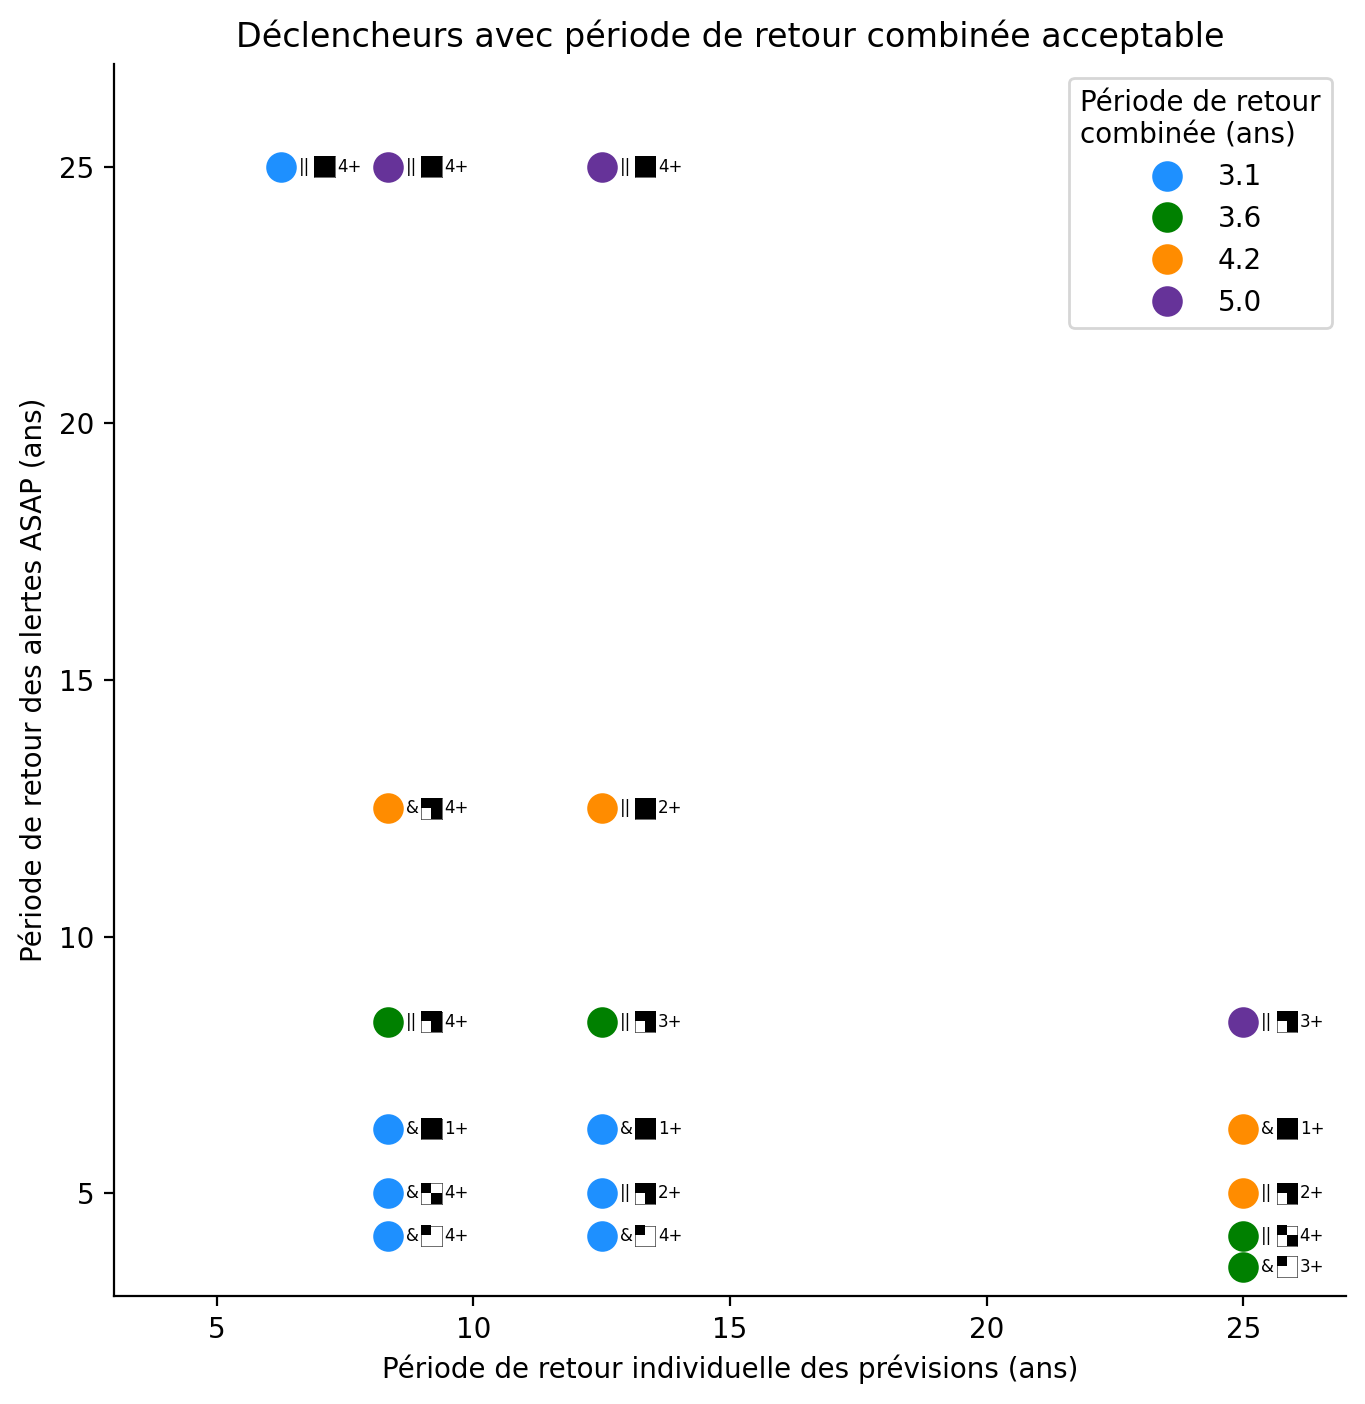

In [50]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=200)

colors = ["dodgerblue", "green", "darkorange", "rebeccapurple"]

df_asap_v_seas5_rp_deduplicated = df_asap_v_seas5_rp.sort_values(
    "rp_com", ascending=True
).drop_duplicates(["rp_asap", "rp_seas5_ind"], keep="first")

for (rp_com, group), color in zip(
    df_asap_v_seas5_rp_deduplicated.groupby("rp_com"), colors
):
    group.plot(
        x="rp_seas5_ind",
        y="rp_asap",
        marker=".",
        linewidth=0,
        ax=ax,
        label=f"{rp_com:.1f}",
        color=color,
        markersize=20,
    )
    for _, row in group.iterrows():
        al, minadm1s, crop_range_fr = extract_asap_params(row["asap_col"])
        ax.annotate(
            "&" if crop_range_fr == "ET" else "||",
            (row["rp_seas5_ind"] + 0.35, row["rp_asap"]),
            ha="left",
            va="center",
            fontsize=6,
        )
        plot_grid(
            row["rp_seas5_ind"] + 0.85,
            row["rp_asap"],
            minadm1s,
            ax,
        )
        ax.annotate(
            al + "+",
            (row["rp_seas5_ind"] + 1.1, row["rp_asap"]),
            ha="left",
            va="center",
            fontsize=6,
        )

ax.legend(title="Période de retour\ncombinée (ans)")
ax.set_xlabel("Période de retour individuelle des prévisions (ans)")
ax.set_ylabel("Période de retour des alertes ASAP (ans)")
ax.set_title("Déclencheurs avec période de retour combinée acceptable")

lims = (3, 27)
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

### Display combined activations

In [51]:
df_both_yearly

,year,issued_3,issued_7,Niveau ≥ 4<br>N. régions ≥ 4<br>Ag. OU Pât.,Niveau ≥ 3<br>N. régions ≥ 4<br>Ag. OU Pât.,Niveau ≥ 2<br>N. régions ≥ 4<br>Ag. OU Pât.,Niveau ≥ 4<br>N. régions ≥ 3<br>Ag. ET Pât.,Niveau ≥ 4<br>N. régions ≥ 3<br>Ag. OU Pât.,Niveau ≥ 2<br>N. régions ≥ 3<br>Ag. ET Pât.,Niveau ≥ 3<br>N. régions ≥ 3<br>Ag. ET Pât.,...,Niveau ≥ 1<br>N. régions ≥ 2<br>Ag. ET Pât.,Niveau ≥ 1<br>N. régions ≥ 2<br>Ag. OU Pât.,Niveau ≥ 1<br>N. régions ≥ 1<br>Ag. ET Pât.,Niveau ≥ 1<br>N. régions ≥ 1<br>Ag. OU Pât.,issued_3_bool,issued_7_bool,issued_3_rank,issued_3_rp,issued_7_rank,issued_7_rp
23,2024,0.545455,0.295455,False,False,False,False,False,False,False,...,True,True,True,True,False,False,14.0,1.785714,8.5,2.941176
22,2023,0.409091,0.840909,False,False,False,False,False,False,False,...,False,False,False,True,False,False,11.0,2.272727,23.0,1.086957
21,2022,0.750000,0.750000,False,False,False,False,False,False,False,...,False,False,False,False,False,False,22.0,1.136364,21.0,1.190476
20,2021,0.704545,0.500000,False,False,False,False,False,False,False,...,True,True,True,True,False,False,20.0,1.250000,15.0,1.666667
19,2020,0.454545,0.181818,False,False,False,False,False,False,False,...,False,True,True,True,False,False,13.0,1.923077,2.0,12.500000
18,2019,0.159091,0.090909,False,False,False,False,False,False,False,...,True,True,True,True,False,False,3.0,8.333333,1.0,25.000000
17,2018,0.568182,0.568182,False,False,False,False,False,False,False,...,False,False,False,False,False,False,16.5,1.515152,18.0,1.388889
16,2017,0.363636,0.272727,False,False,False,False,False,False,False,...,True,True,True,True,False,False,8.5,2.941176,6.0,4.166667
15,2016,0.295455,0.409091,False,False,False,False,False,False,False,...,False,False,False,True,False,False,6.0,4.166667,13.0,1.923077
14,2015,0.204545,0.613636,False,False,False,False,False,False,False,...,True,True,True,True,False,False,4.0,6.250000,19.0,1.315789


In [52]:
def display_combined_activations(asap_col, rp_seas5_ind):
    df_disp = df_both_yearly.rename(columns={"year": "Année"}).set_index(
        "Année"
    )
    cols = []
    for mo in [3, 7]:
        col = f"Prévisions de<br>{FRENCH_MONTHS[calendar.month_abbr[mo]]}"
        df_disp[col] = df_disp[f"issued_{mo}_rp"] > rp_seas5_ind
        print(f"fcast {mo} rp:")
        print((len(df_disp) + 1) / df_disp[col].sum())
        print()
        cols.append(col)
    df_disp = df_disp[cols + [asap_col]]
    print(f"fcast combined rp:")
    print((len(df_disp) + 1) / df_disp[cols].any(axis=1).sum())
    print()
    print("asap rp:")
    print((len(df_disp) + 1) / df_disp[asap_col].sum())
    print()
    print("combined rp:")
    print((len(df_disp) + 1) / df_disp.any(axis=1).sum())
    display(
        df_disp.replace(
            {True: "Activation", False: "Pas d'activation"}
        ).style.map(highlight_true)
    )

In [53]:
asap_col = ASAP_COL.format(al=4, minadm1s=1, crop_range_fr="ET")
display_combined_activations(asap_col, 8)

fcast 3 rp:
8.333333333333334

fcast 7 rp:
12.5

fcast combined rp:
6.25
fcast combined prob:
0.16

asap rp:
4.166666666666667
asap prob:
0.24

combined rp:
3.125
combined prob:
0.32


,Prévisions demars,Prévisions dejuil.,Niveau ≥ 4N. régions ≥ 1Ag. ET Pât.
Année,,,
2024,Pas d'activation,Pas d'activation,Pas d'activation
2023,Pas d'activation,Pas d'activation,Pas d'activation
2022,Pas d'activation,Pas d'activation,Pas d'activation
2021,Pas d'activation,Pas d'activation,Pas d'activation
2020,Pas d'activation,Activation,Pas d'activation
2019,Activation,Activation,Activation
2018,Pas d'activation,Pas d'activation,Pas d'activation
2017,Pas d'activation,Pas d'activation,Pas d'activation
2016,Pas d'activation,Pas d'activation,Pas d'activation


In [54]:
asap_col = ASAP_COL.format(al=4, minadm1s=1, crop_range_fr="ET")
display_combined_activations(asap_col, 7)

fcast 3 rp:
8.333333333333334

fcast 7 rp:
12.5

fcast combined rp:
6.25
fcast combined prob:
0.16

asap rp:
4.166666666666667
asap prob:
0.24

combined rp:
3.125
combined prob:
0.32


,Prévisions demars,Prévisions dejuil.,Niveau ≥ 4N. régions ≥ 1Ag. ET Pât.
Année,,,
2024,Pas d'activation,Pas d'activation,Pas d'activation
2023,Pas d'activation,Pas d'activation,Pas d'activation
2022,Pas d'activation,Pas d'activation,Pas d'activation
2021,Pas d'activation,Pas d'activation,Pas d'activation
2020,Pas d'activation,Activation,Pas d'activation
2019,Activation,Activation,Activation
2018,Pas d'activation,Pas d'activation,Pas d'activation
2017,Pas d'activation,Pas d'activation,Pas d'activation
2016,Pas d'activation,Pas d'activation,Pas d'activation


In [54]:
asap_col = ASAP_COL.format(al=4, minadm1s=3, crop_range_fr="ET")
display_combined_activations(asap_col, 5)

fcast 3 rp:
6.25

fcast 7 rp:
5.0

fcast combined rp:
3.5714285714285716

asap rp:
12.5

combined rp:
2.7777777777777777


,Prévisions demars,Prévisions dejuil.,Niveau ≥ 4N. régions ≥ 3Ag. ET Pât.
Année,,,
2024,Pas d'activation,Pas d'activation,Pas d'activation
2023,Pas d'activation,Pas d'activation,Pas d'activation
2022,Pas d'activation,Pas d'activation,Pas d'activation
2021,Pas d'activation,Pas d'activation,Pas d'activation
2020,Pas d'activation,Activation,Pas d'activation
2019,Activation,Activation,Pas d'activation
2018,Pas d'activation,Pas d'activation,Pas d'activation
2017,Pas d'activation,Pas d'activation,Pas d'activation
2016,Pas d'activation,Pas d'activation,Pas d'activation
